# <a href="https://girafe.ai/" target="_blank" rel="noopener noreferrer"><img src="https://raw.githubusercontent.com/girafe-ai/ml-course/7096a5df4cada5ee651be1e3215c2f7fb8a7e0bf/logo_margin.svg" alt="girafe-ai logo" width="150px" align="left"></a> [ml-basic course](https://github.com/girafe-ai/ml-course) <a class="tocSkip">

# Almost Shakespeare

Let's try to generate some Shakespeare poetry using RNNs. The sonnets file is available in the notebook directory.

Text generation can be designed in several steps:
    
1. Data loading
2. Dictionary generation
3. Data preprocessing
4. Model (neural network) training
5. Text generation (model evaluation)

### Data loading

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`).

Simple preprocessing is already done for you in the next cell: all technical info is dropped.

**Alternatively**

You could use file `onegin.txt` with Russian texts or your natve language poetry to be able to assess results quality.

**Note: In case of Onegin text you need to adjust reading procedure yourself!!!** (this file has a bit different format than `sonnets.txt`)

In [1]:
!wget -nc https://raw.githubusercontent.com/v-goncharenko/madmo-adv/55d929befa12370fc18109f5333f7cf000ea27ce/homeworks/sonnets.txt
!wget -nc https://raw.githubusercontent.com/v-goncharenko/madmo-adv/55d929befa12370fc18109f5333f7cf000ea27ce/homeworks/onegin.txt

File ‘sonnets.txt’ already there; not retrieving.

File ‘onegin.txt’ already there; not retrieving.



In [2]:
with open("sonnets.txt", "r") as iofile:
    text = iofile.readlines()

TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START:TEXT_END]
#assert len(text) == 2616

print('\n'.join(text[:10]))

  From fairest creatures we desire increase,

  That thereby beauty's rose might never die,

  But as the riper should by time decease,

  His tender heir might bear his memory:

  But thou, contracted to thine own bright eyes,

  Feed'st thy light's flame with self-substantial fuel,

  Making a famine where abundance lies,

  Thy self thy foe, to thy sweet self too cruel:

  Thou that art now the world's fresh ornament,

  And only herald to the gaudy spring,



In [3]:
sonnets_idx = []
for i in range(1, len(text)-1):
    if text[i-1] == "\n" and text[i+1] == "\n":
        sonnets_idx.append(i)

sonnets = [text[:14]]
for i in range(0, len(sonnets_idx)-1):
    idx_s = sonnets_idx[i]+2
    idx_t = sonnets_idx[i+1]-1
    sonnets.append(text[idx_s:idx_t])
sonnets.append(text[sonnets_idx[-1]+2:])
len(sonnets)

154

In [4]:
import random
random.seed(49)
random.shuffle(sonnets)
val_text_s = sonnets[0:30]
train_text_s = sonnets[30:]

## Preprocessing

In opposite to the in-class practice, this time we want to predict complex text.

In class we've discussed ways to preprocess textual data. You need to choose your way to preprocess data, tokenize it and pack it to samples.

You could use preprocessing from text translation class.

In [5]:
import string

In [6]:
def sonnet_to_str(sonnet):
    s = ""
    for i in sonnet:
        s += i.lstrip().lower()
    return s

In [10]:
train_text = [sonnet_to_str(i) for i in train_text_s]
val_text = [sonnet_to_str(i) for i in val_text_s]

Put all the tokens, that you've seen in the text, into variable.

Create dictionary `token_to_idx = {<token>: <index>}` and dictionary `idx_to_token = {<index>: <token>}`

In [11]:
def calc_stat(arr):
    d = {}
    for pair in zip(arr, arr[1:]):
        d[pair] = d.get(pair, 0) + 1
    return d

def merge(arr, parents, new_idx):
    i = 0
    new_arr = []
    while i < len(arr):
        if  i+1 < len(arr) and arr[i] == parents[0] and arr[i+1] == parents[1]:
            new_arr.append(new_idx)
            i += 2
        else:
            new_arr.append(arr[i])
            i += 1
    return new_arr

a = [1, 1, 1, 2, 1, 1, 10, 98, 1, 3, 2, 1, 1]
print(calc_stat(a))
print(a)
print(merge(a, (1, 1), -1))

{(1, 1): 4, (1, 2): 1, (2, 1): 2, (1, 10): 1, (10, 98): 1, (98, 1): 1, (1, 3): 1, (3, 2): 1}
[1, 1, 1, 2, 1, 1, 10, 98, 1, 3, 2, 1, 1]
[-1, 1, 2, -1, 10, 98, 1, 3, 2, -1]


In [12]:
# gpt style tokenizer
# in this cell we will try to estimate the size of final vocab
tokens = list(set(" ".join(train_text)))
stoi = {s : i for i, s in enumerate(tokens)}
itos = {i : s for s, i in stoi.items()}


x = []
y = []

seq = [stoi[ch] for ch in " ".join(train_text)]
for i in range(1000):
    x.append(len(tokens))
    y.append(len(seq))
    #print(f"amount of tokens = {len(seq)}\nvocab_size={len(tokens)}")
    stat = calc_stat(seq)
    stat = sorted(stat.items(), key=lambda x: -x[1])
    if stat[0][1] == 1:
        break
    new_token = itos[stat[0][0][0]] + itos[stat[0][0][1]]
    tokens.append(new_token)
    stoi[new_token] = len(tokens)
    itos[len(tokens)-1] = new_token
    seq = merge(seq, stat[0][0], len(tokens) - 1)
#print(f"amount of token = {len(seq)}\nvocab_size={len(tokens)}")

Text(0, 0.5, 'amount_of_tokens')

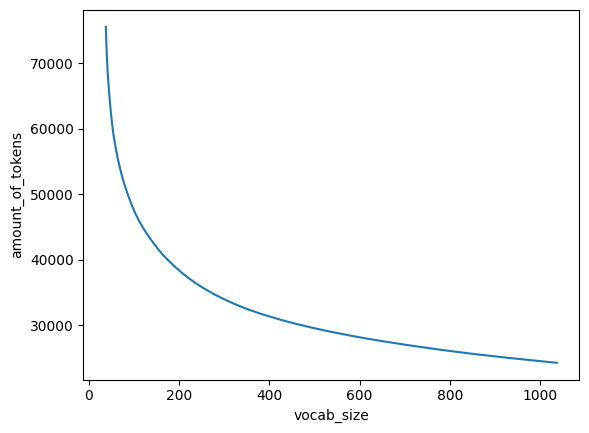

In [13]:
# according to plot choose vocab_size=50
import matplotlib.pyplot as plt
plt.plot(x, y)
plt.xlabel("vocab_size")
plt.ylabel("amount_of_tokens")

In [81]:
tokens = list(set(" ".join(train_text)))
new_tokens = []

stoi = {s : i for i, s in enumerate(tokens)}
itos = {i : s for s, i in stoi.items()}
seq = [stoi[ch] for ch in " ".join(train_text)]

# params
initial_vocab_size = len(tokens)
vocab_size = 50
size = initial_vocab_size

for i in range(vocab_size-initial_vocab_size):
    stat = calc_stat(seq)
    stat = sorted(stat.items(), key=lambda x: -x[1])
    if stat[0][1] == 1:
        break
    new_token = itos[stat[0][0][0]] + itos[stat[0][0][1]]
    new_tokens.append(new_token)
    size += 1
    stoi[new_token] = size - 1
    itos[size - 1] = new_token
    seq = merge(seq, stat[0][0], size - 1)

#'*' - SOS and EOS tokens; '#' - pad token
tokens.append("*")
stoi["*"] = len(tokens) + len(new_tokens) - 1
itos[len(tokens) + len(new_tokens) - 1] = "*"
tokens.append("#")
stoi["#"] = len(tokens) + len(new_tokens) - 1
itos[len(tokens) + len(new_tokens) - 1] = "#"
vocab_size += 2
print(f"amount of tokens = {len(seq)}\nvocab_size = {len(tokens) + len(new_tokens)}")

amount of tokens = 61891
vocab_size = 52


In [82]:
print(tokens)

['m', 'z', ';', ')', 'j', 'p', 'q', "'", 'd', '.', 't', 'c', 'a', 's', ':', 'n', ',', 'h', 'i', 'w', '(', 'y', 'k', '!', ' ', 'g', 'e', '-', 'r', 'o', 'b', 'f', '\n', 'v', '?', 'l', 'u', 'x', '*', '#']


In [83]:
print(new_tokens)

['th', 'e ', 't ', 's ', 'in', 'y ', 'd ', 'ou', ' th', 'an', ',\n', 'er']


*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

In [84]:
import torch
import torch.utils.data as data

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

In [85]:
def encode(s):
    seq = list(s)
    for i in range(0, len(new_tokens)):
        pair = new_tokens[i]
        idx = 0
        new_seq = []
        while idx < len(seq):
            if idx+1 < len(seq) and seq[idx] + seq[idx+1] == pair:
                idx += 2
                new_seq.append(pair)
            else:
                new_seq.append(seq[idx])
                idx += 1
        seq = new_seq
    arr = [stoi[ch] for ch in seq]
    return arr

def decode(arr):
    s = ""
    for i in arr:
        s += itos[i]
    return s

arr = encode("the cat in car")
print(arr)
decode(arr)

[38, 39, 11, 12, 40, 42, 24, 11, 12, 28]


'the cat in car'

In [86]:
print(stoi)

{'m': 0, 'z': 1, ';': 2, ')': 3, 'j': 4, 'p': 5, 'q': 6, "'": 7, 'd': 8, '.': 9, 't': 10, 'c': 11, 'a': 12, 's': 13, ':': 14, 'n': 15, ',': 16, 'h': 17, 'i': 18, 'w': 19, '(': 20, 'y': 21, 'k': 22, '!': 23, ' ': 24, 'g': 25, 'e': 26, '-': 27, 'r': 28, 'o': 29, 'b': 30, 'f': 31, '\n': 32, 'v': 33, '?': 34, 'l': 35, 'u': 36, 'x': 37, 'th': 38, 'e ': 39, 't ': 40, 's ': 41, 'in': 42, 'y ': 43, 'd ': 44, 'ou': 45, ' th': 46, 'an': 47, ',\n': 48, 'er': 49, '*': 50, '#': 51}


In [235]:
stats = []
for s in train_text_s:
    for j in s:
        enc = encode(j.lstrip().lower())
        stats.append(len(enc))

49


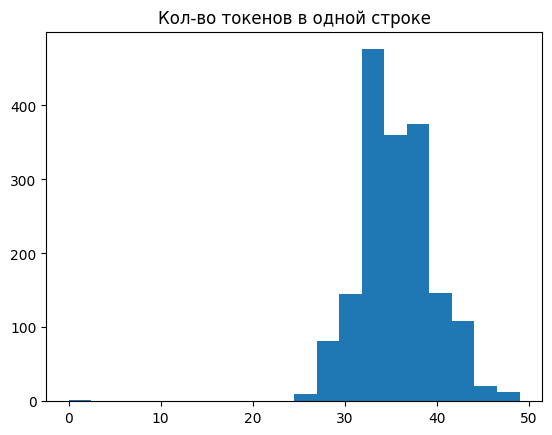

In [236]:
plt.hist(stats, bins=20)
plt.title('Кол-во токенов в одной строке')
print(max(stats))

In [237]:
context_len = max(stats)
emb_size = 16
batch_size = 256
device  =  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [239]:
class dataset(data.Dataset):
    def __init__(self, sonnets_array, context_len):
        x_ds = []
        y_ds = []
        length = 0
        for sonnet in sonnets_array:
            for line in sonnet:
                enc = encode(line.lstrip().lower())
                enc_size = len(enc)
                enc = [stoi['*']] + enc + [stoi['#']] * (context_len - enc_size)
                x_ds.append(enc[:-1])
                y_ds.append(enc[1:])
                length += 1
                
        self.x = torch.tensor(x_ds, dtype=torch.int64)
        self.y = torch.tensor(y_ds, dtype=torch.int64)
        self.length = length
    def __getitem__(self, item):
        return self.x[item], self.y[item]
        
    def __len__(self):
        return self.length

In [248]:
ds = dataset(train_text_s, context_len)
dl = data.DataLoader(ds, batch_size=1, shuffle=False)

In [251]:
for d in dl:
    print(d[0].shape)
    print(d[0])
    print(decode(d[0].numpy()))
    break

torch.Size([1, 49])
tensor([[50, 19, 49, 26,  7, 40, 12, 36, 25, 17, 40, 10, 29, 24,  0, 39, 18, 24,
         30, 29, 28, 39, 38, 39, 11, 47, 29,  5, 21, 48, 51, 51, 51, 51, 51, 51,
         51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51, 51]])


TypeError: unhashable type: 'numpy.ndarray'

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [117]:
class vanilla_cell (nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_state_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_size)
        self.h0 = nn.Embedding(1, hidden_state_size)
        self.rnn_cell = nn.RNNCell(emb_size, hidden_state_size, nonlinearity="tanh")
        self.clf_head = nn.Linear(hidden_state_size, vocab_size)
        
    def forward(self, x, prev_hs):
        if prev_hs == None:
            prev_hs = self.h0(torch.zeros((x.shape[0], 1), dtype=torch.int64))
            prev_hs = prev_hs.view((prev_hs.shape[0], -1))
        print(prev_hs.shape)
        x_emb = self.emb(x).view((x.shape[0], -1))
        print(x.shape)
        print(x_emb.shape)
        hs = self.rnn_cell(x_emb, prev_hs)
        logits = self.clf_head(hs)
        return hs, logits     

In [113]:
def rnn_loop(rnn_cell, batch_ix):
    batch_size, max_length = batch_ix.size()
    hid_state = None
    logprobs = []

    for x_t in batch_ix.transpose(0, 1): # shape = object_len, bs, emb_dim
        hid_state, logits = char_rnn(x_t, hid_state)  # <-- here we call our one-step code
        logprobs.append(F.log_softmax(logits, -1))

    return torch.stack(logprobs, dim=1)

Plot the loss function (axis X: number of epochs, axis Y: loss function).

In [140]:
ds = dataset(train_text_s, context_len)
dl = data.DataLoader(ds, batch_size=batch_size)

49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
50
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
49
4

ValueError: expected sequence of length 48 at dim 1 (got 49)

In [ ]:
# An example of generated text. There is no function `generate_text` in the code above.
# print(generate_text(length=500, temperature=0.2))

hide my will in thine?
  shall will in of the simend that in my sime the seave the seave the sorll the soren the sange the seall seares and and the fart the wirl the seall the songh whing that thou hall will thoun the soond beare the with that sare the simest me the fart the wirl the songre the with thy seart so for shat so for do the dost the sing the sing the sing the soond canding the sack and the farling the wirl of sore sich and that with the seare the seall so fort the with the past the wirl the simen the wirl the sores the sare


### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [ ]:
# Your beautiful code here

Generate text using the trained net with different `temperature` parameter: `(0.1, 0.2, 0.5, 1.0, 2.0)`.

Evaluate the results visually, try to interpret them.

In [ ]:
# Text generation with different temperature values here

### Saving and loading models

Save the model to the disk, then load it and generate text.
Follow guides from [this tutorial](https://pytorch.org/tutorials/beginner/saving_loading_models.html).

You need to use `Save/Load state_dict (Recommended)` section aka save state dict.

In [ ]:
# Saving and loading code here

## Additional materials on topic

1. [Andrew Karpathy blog post about RNN.](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)\
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with [PyTorch examples](https://github.com/spro/practical-pytorch`)